# ChurnScope AI — Forecast → Classify → Explain → Act

**Academic project notebook · subscription-based learning platform**

## A — Problem definition

We study five separate tasks: segment similar histories, estimate next-window churn risk, forecast weekly usage, explain a fitted classifier, and select an eligible retention action.

```text
Customer history → Segmentation → Churn classifier → Usage forecast → SHAP → Preferences → Decision agent
```

**Clustering ≠ classification ≠ forecasting ≠ LLM reasoning.** Clusters summarize behavioral similarity; the classifier predicts a defined outcome; forecasts project a separate usage series; the agent selects a policy-permitted response from verified evidence. SHAP describes model contributions, not causes.

## B — Synthetic data generation

Generate 300 learners and 32 weekly observations per learner with fixed seed 42. Subscription age starts once per learner and increases by one each week. Outcomes are probabilistic and behavior-driven; no demo customer's probability or target is forced.

In [1]:
from pathlib import Path
import sys, json, joblib
import numpy as np, pandas as pd
from IPython.display import display, Markdown
ROOT=Path.cwd()
if not (ROOT/'scripts').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT)); sys.path.insert(0,str(ROOT/'scripts'))
from scripts.generate_data import generate, PREDICTION_CUTOFF
history, profiles, targets = generate()
print('Weekly history:', history.shape, '| Profiles:', profiles.shape, '| Churn targets:', targets.shape)
display(history.head()); display(profiles.head()); display(targets.head())

Weekly history: (9600, 12) | Profiles: (300, 7) | Churn targets: (300, 7)


,customer_id,week,weekly_sessions,active_days,usage_minutes,completed_lessons,completed_labs,searches,support_requests,days_since_last_activity,subscription_age_weeks,cancelled
0,C001,1,12,7,290.7,5,2,6,0,8,49,0
1,C001,2,13,7,433.7,5,3,7,0,2,50,0
2,C001,3,16,6,507.3,5,1,7,0,5,51,0
3,C001,4,14,7,313.0,8,2,1,0,0,52,0
4,C001,5,14,6,407.8,8,3,1,0,5,53,0


,customer_id,age_group,favorite_topic,preferred_content_type,preferred_feature,preferred_study_time,historical_engagement_level
0,C001,25–34,Deep Learning,Videos,Projects,Evening,High
1,C002,45+,Data Analysis,Interactive Labs,Practice Problems,Weekend,High
2,C003,45+,Data Analysis,Quizzes,Interactive Labs,Weekend,High
3,C004,25–34,Deep Learning,Quizzes,Learning Paths,Weekend,High
4,C005,45+,Python,Projects,Interactive Labs,Morning,High


,customer_id,prediction_cutoff_week,outcome_window_start_week,outcome_window_end_week,will_churn_next_4_weeks,cancellation_week,synthetic_churn_propensity
0,C001,28,29,32,0,NaN,0.026659
1,C002,28,29,32,1,30.0,0.950572
2,C003,28,29,32,1,32.0,0.998630
3,C004,28,29,32,0,NaN,0.000287
4,C005,28,29,32,0,NaN,0.373528


## C — Prediction cutoff and churn target

We observe customer behavior up to **week 28** and predict whether they will churn during the following four-week window, **weeks 29–32**. The target is stored separately at customer level. Weeks 29–32 cannot enter classifier feature construction.

In [2]:
from scripts.export_models import engineer_features, FEATURES
features = engineer_features(history, cutoff=PREDICTION_CUTOFF)
assert set(features.customer_id) == set(targets.customer_id)
assert not any(name in FEATURES for name in ('cancelled','will_churn_next_4_weeks'))
assert 'will_churn_next_4_weeks' not in features.columns
print('Observed weeks:', history.loc[history.week<=28,'week'].min(), 'to', history.loc[history.week<=28,'week'].max())
print('Outcome weeks:', targets.outcome_window_start_week.iloc[0], 'to', targets.outcome_window_end_week.iloc[0])
display(targets.will_churn_next_4_weeks.value_counts().rename('customers').to_frame())
display(features[['customer_id','subscription_age_weeks','recent_sessions','sessions_trend','recent_usage_minutes','usage_trend']].head())

Observed weeks: 1 to 28
Outcome weeks: 29 to 32


,customers
will_churn_next_4_weeks,
0,190
1,110


,customer_id,subscription_age_weeks,recent_sessions,sessions_trend,recent_usage_minutes,usage_trend
0,C001,76,16.00,1.75,439.750,41.75
1,C002,83,6.50,-4.00,175.000,-116.25
2,C003,41,2.25,-7.50,71.500,-199.75
3,C004,50,9.00,5.25,245.000,154.50
4,C005,97,11.75,-2.25,380.725,-35.30


## D — Exploratory data analysis

Forecast validation windows are separate from the classifier's target window: historical cutoffs **20 → 21–24**, **24 → 25–28**, and **28 → 29–32**. Each forecast fold uses only values available at its cutoff.

,count,mean,std,min,25%,50%,75%,max
weekly_sessions,32.0,7.22,0.92,5.83,6.26,7.47,8.07,8.57
usage_minutes,32.0,202.73,25.88,161.88,177.88,209.97,222.17,244.37
active_days,32.0,3.47,0.42,2.83,3.05,3.59,3.86,4.14
completed_lessons,32.0,3.33,0.44,2.71,2.88,3.38,3.68,4.04


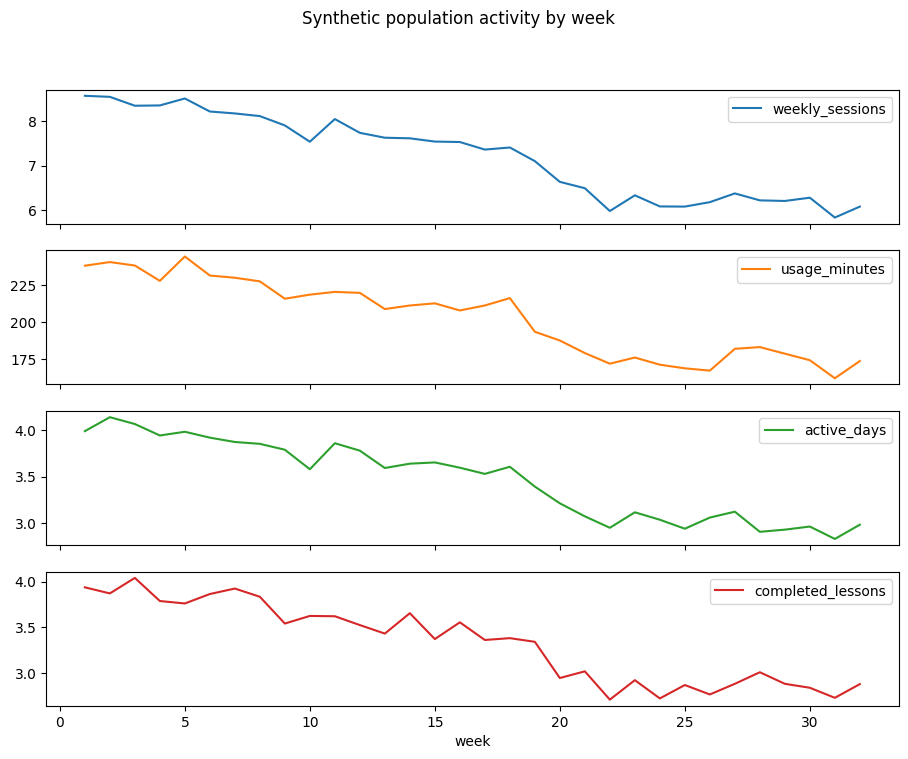

In [3]:
weekly = history.groupby('week')[['weekly_sessions','usage_minutes','active_days','completed_lessons']].mean()
display(weekly.describe().round(2).T)
weekly.plot(subplots=True, figsize=(11,8), title='Synthetic population activity by week');

## E — Feature engineering and leakage audit

All classifier features are calculated from rows with `week <= 28`. The customer-level target is joined only after feature construction. Subscription-age monotonicity is checked per learner.

In [4]:
age_steps = history.sort_values(['customer_id','week']).groupby('customer_id').subscription_age_weeks.diff().dropna()
assert (age_steps == 1).all()
assert set(FEATURES).issubset(features.columns)
assert not set(FEATURES) & {'cancelled','will_churn_next_4_weeks','synthetic_churn_propensity'}
assert features.subscription_age_weeks.notna().all()
print(f'Monotonic age increments: {len(age_steps)} / {len(age_steps)}')
print('Classifier schema:', len(FEATURES), 'features; label stored separately.')

Monotonic age increments: 9300 / 9300
Classifier schema: 22 features; label stored separately.


## F — Customer segmentation

K-Means assigns every learner to a behavioral group for map visualization. Names use cluster-level recent sessions and usage, engagement trends, volatility, inactivity, active days, and lesson completion. DBSCAN is retained as a density-based comparison. Segmentation is exploratory: overlapping histories and low silhouette scores limit claims of natural separation. K-Means is used for complete map coverage and stable behavioral profiling, not because it is objectively superior.

## G — Churn classification

Logistic Regression and Random Forest are compared on a customer-level holdout. Selection emphasizes recall, ROC-AUC, and F1; the selected model is refit on all cutoff snapshots for the demo. Risk tiers are policy thresholds over estimated probabilities.

In [5]:
from scripts.export_models import train_export
train_export()
metrics = json.loads((ROOT/'models/metrics.json').read_text(encoding='utf-8'))
bundle = joblib.load(ROOT/'models/pipeline.joblib')
display(pd.DataFrame(metrics['classification']['models']).T.round(3))
display(Markdown(f"**Selected classifier:** {metrics['classification']['selected_model']} · cutoff week 28 · target: weeks 29–32."))
display(pd.DataFrame(metrics['clustering']['cluster_stats']).T.round(2))
display(pd.DataFrame(metrics['clustering']['cluster_naming_rationale']).T[['label','rule']])

Exported 300 cutoff snapshots. Churn rate=36.7%, classifier=Logistic Regression, forecast=exp_smoothing.


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.787,0.657,0.852,0.742,0.89
Random Forest,0.787,0.677,0.778,0.724,0.85


**Selected classifier:** Logistic Regression · cutoff week 28 · target: weeks 29–32.

,customers,recent_sessions,recent_usage_minutes,usage_trend,sessions_trend,active_days_trend,usage_slope_recent,sessions_slope_recent,engagement_volatility,days_since_last_activity,active_days,lesson_completion_rate
0,80.0,4.50,124.53,-22.31,-0.75,-0.50,-4.70,-0.17,76.71,16.49,3.21,0.45
1,31.0,9.55,281.25,114.99,3.23,1.81,24.30,0.63,112.68,9.33,3.94,0.46
2,59.0,8.60,232.62,-48.07,-1.33,-0.50,-7.74,-0.22,98.40,8.57,4.59,0.47
3,85.0,1.18,38.47,-5.33,-0.22,-0.04,-1.31,-0.06,33.49,43.38,1.94,0.46
4,45.0,13.36,374.68,38.23,1.21,0.14,8.20,0.24,115.47,6.18,5.52,0.46


,label,rule
4,Power Users,highest standardized recent usage and sessions
0,Core Engaged,remaining cluster after behavioral extremes ar...
2,Fading Engagement,"most negative combined usage, session, and act..."
3,Low Activity,lowest standardized recent usage and sessions
1,Irregular Users,highest engagement volatility among remaining ...


## H — Time-series forecasting

Forecasting is a distinct task from churn classification. We compare naive last value, damped exponential smoothing, ARIMA(1,1,0), and an explainable ridge lag-feature model using chronological walk-forward windows. No time-series rows are randomly shuffled. MAE is the primary selection metric; RMSE and sMAPE are secondary. MAPE is unstable when actual usage approaches zero, so it is not used for selection. Forecast errors remain empirical and non-trivial.

In [6]:
forecast_metrics = metrics['forecasting']['metrics']
display(pd.DataFrame(forecast_metrics).T[['mae','rmse','smape','mase','mape','fallback_folds']].round(2))
print('Selected global model:', metrics['forecasting']['selected_model'])
from backend.forecasting import forecast
fc = forecast('C003')
assert len(fc['forecast']) == 4
display(pd.DataFrame(fc['history'][-8:] + fc['forecast']))

,mae,rmse,smape,mase,mape,fallback_folds
naive,98.96,138.04,75.94,0.88,161.83,0.0
exp_smoothing,85.53,119.61,68.47,0.77,174.07,0.0
arima,92.78,128.93,71.94,0.83,168.46,0.0
lag_regression,97.31,129.55,70.95,0.88,233.84,0.0


Selected global model: exp_smoothing


,week,usage_minutes,lower,upper
0,25,155.000000,NaN,NaN
1,26,92.000000,NaN,NaN
2,27,35.000000,NaN,NaN
3,28,4.000000,NaN,NaN
4,29,75.700000,NaN,NaN
5,30,115.400000,NaN,NaN
6,31,65.200000,NaN,NaN
7,32,26.200000,NaN,NaN
8,33,24.540420,0.0,215.256972
9,34,23.212755,0.0,213.929307


## I — SHAP explainability

SHAP values are model contribution values. They are not percentages, causal effects, or proof that a feature caused churn. Positive contributions move the fitted model output upward; negative contributions move it downward.

In [7]:
from backend.explainability import explanation
shap_result = explanation('C003')
display(pd.DataFrame(shap_result['values']))

C:\Users\LAPSHOP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,label,value
0,usage_trend,Usage trend,5.374486
1,active_days_trend,Active days trend,0.785755
2,recent_usage_minutes,Recent usage,0.577224
3,recent_completed_lessons,Lesson completion,0.568021
4,lab_usage_rate,Lab Usage Rate,-0.430996
5,activity_lag_1,Activity Lag 1,0.406847
6,days_since_last_activity,Recent inactivity,0.347637
7,activity_lag_2,Activity Lag 2,-0.285869


## J — Customer preferences

Preferences are recorded profile data, separate from classifier evidence. The eligibility policy uses topic/content/feature preferences alongside risk, engagement change, and support requests.

In [8]:
from backend.customer_service import profile
from backend.decision_policy import eligible_actions, deterministic_recommendation
for cid in ('C001','C002','C003','C004'):
    p=profile(cid)
    print(cid, p['risk'], f"probability={p['churn_probability']:.3f}", p['segment'])
p=profile('C003')
display(pd.Series(p['preferences'], name='Recorded preferences'))

C001 STABLE probability=0.089 Power Users
C002 CRITICAL probability=0.956 Fading Engagement
C003 CRITICAL probability=0.999 Core Engaged
C004 STABLE probability=0.001 Irregular Users


age_group                                   45+
favorite_topic                    Data Analysis
preferred_content_type                  Quizzes
preferred_feature              Interactive Labs
preferred_study_time                    Weekend
historical_engagement_level                High
Name: Recorded preferences, dtype: object

## K — Agentic retention decision layer

The QA prompt answers evidence questions in natural language. A separate recommendation prompt returns structured JSON and can select only from the deterministic eligibility list. Verified model evidence and AI wording remain visibly distinct. Action execution is an in-memory simulation and sends no real message.

In [9]:
print('Eligible actions:', eligible_actions('C003'))
display(pd.Series(deterministic_recommendation('C003')))

Eligible actions: ['PREMIUM_FEATURE_TRIAL', 'RE_ENGAGEMENT_MESSAGE', 'PERSONALIZED_CONTENT_RECOMMENDATION', 'STUDY_PLAN_RECOMMENDATION', 'LEARNING_PATH_RECOMMENDATION', 'ONE_FREE_MONTH']


action                                          PREMIUM_FEATURE_TRIAL
action_label                              7-day premium feature trial
reason              The learner has historically high engagement, ...
message             Hi! Since you prefer Interactive Labs, you can...
provider                                                deterministic
fallback                                                         True
eligible_actions    [PREMIUM_FEATURE_TRIAL, RE_ENGAGEMENT_MESSAGE,...
dtype: object

## L — Limitations

- The dataset is synthetic, fixed-seed, and small; holdout scores do not establish real-world performance.
- Behavioral clusters overlap; silhouette is reported rather than hidden.
- Forecast errors remain non-trivial, and the empirical interval is not formally calibrated.
- SHAP explains the fitted classifier and is not causal.
- The optional local language model may make wording errors; unsupported numbers/actions fall back to deterministic output.
- Recommendations and action execution are simulated; no messages are sent.

## M — Exported artifacts

The application loads the same pipeline exported here. Model metrics include classifier holdout results, clustering diagnostics and naming rationale, and all forecasting candidate metrics. The weekly table keeps outcome-window rows for EDA/forecast validation, while classifier features remain cutoff-bounded.

In [10]:
print('Dataset:', metrics['dataset'])
print('Artifacts:', ROOT/'models/pipeline.joblib', ROOT/'models/metrics.json')
print('Forecast selection:', metrics['forecasting']['selected_model'], metrics['forecasting']['selection_rule'])

Dataset: {'customers': 300, 'weekly_records': 9600, 'churn_rate': 0.36666666666666664, 'weeks_per_customer': 32, 'prediction_cutoff_week': 28, 'outcome_window_weeks': [29, 30, 31, 32]}
Artifacts: C:\Users\LAPSHOP\Documents\Time Forecasting project\models\pipeline.joblib C:\Users\LAPSHOP\Documents\Time Forecasting project\models\metrics.json
Forecast selection: exp_smoothing lowest MAE; RMSE and sMAPE are secondary evidence
